# Implementacão - Python 3.14 (threading)

## Detalhes

1. GIL free
- Python 3.14 não prossui a trava de GIL (Global Interpreter Lock) ou seja é "free-threaded". Isso significa que ao executar um programa Python com múltiplas threads não haverá bloqueio entre as threads, comportamento aplicado pelo GIL que serializava sua execução. Com Python 3.14 o comportamento das threads é de fato paralelo.

2. Multiprocessing vs Threading
- Com *multiprocessing* o comportamento é semelhante ao Python 3.12
- Já com *threading* há compartilhamento real de memória.


## Instalação Python 3.14.0t (sem GIL)

1. Verificação das versões disponíveis

```python
pyenv install --list | grep 3.14
  3.14.0
  3.14.0t
  3.14-dev
  3.14t-dev
  miniconda2-4.3.14
  miniconda3-4.3.14
  pypy2.7-7.3.14-src
  pypy2.7-7.3.14
  pypy3.9-7.3.14-src
  pypy3.9-7.3.14
  pypy3.10-7.3.14-src
  pypy3.10-7.3.14
```

2. Seleção da versão correta (sem GIL)

- 3.14.0t: Recomendada. É a versão **estável** (não-dev) do Python 3.14 já **compilada com o suporte Free-Threaded (sem GIL)**. O sufixo *t* é o indicativo oficial disso.
    - Não é necessário usar a variável PYTHON_CONFIGURE_OPTS="--disable-gil" para a versão 3.14.0t, pois o *pyenv* já sabe que essa variante deve ser compilada sem o GIL.

- 3.14.0: Versão padrão do Python 3.14 com GIL. Não atende ao seu objetivo.

3. Instalação d aversão free-threaded (sem GIL)

```python
pyenv install 3.14.0t
```

4. Ativação da nova versão
- Isso garantirá que 'python' neste diretório use a versão sem GIL

```python
pyenv local 3.14.0t
```

5. Verificar versão

```python
python --version
> Python 3.14.0
```

6. Atualizar atalhos (*Shims*)
- Necessário recirar os atalhos de comando (shims) para os novos executáveis (como o jupyter) dentro da versão 3.14.0t que foi aitvada

```python
pyenv rehash
```

- Agora ```jupyter notebook``` deve funcionar
- Se ainda houver problemas, o comando python abaixo usará a versão 3.14.0t ativa

```python
python -m pip install notebook jupyterlab
```


## Configuração ipykernel para Jupyer Notebook

1. Exclusão do kernel antigo (com GIL)
- Excluir kernel associado à versão 3.14.0 que ainda possui GIL.

```python
jupyter kernelspec uninstall python-3.14
```

2. Ativar a Versão Python 3.14.0t (Sem GIL)
- Certifique-se de que o *pyenv* está usando a versão 3.14.0t (a versão sem GIL) para que o ipykernel seja instalado nesse ambiente.

```python
pyenv local 3.14.0t
```

3. Instalar o *ipykernel* e o *notebook*
- Dentro do ambiente 3.14.0t:

```python
python -m pip install ipykernel notebook --proxy "http://proxy.tjrs.gov.br:8080"
pip install --upgrade pip --proxy "http://proxy.tjrs.gov.br:8080"
```

4. Criar o Novo Kernel (Sem GIL)

```python
python -m ipykernel install --user --name "python-3.14t-nogil" --display-name "Python 3.14 (No GIL)"
```

## Execução do Jupyer Notebook

1. No terminal:
    
```bash
OPENBLAS_NUM_THREADS=1 PYTHON_GIL=0 jupyter notebook
```

- *OPENBLAS_NUM_THREADS=1* força o numpy a executar a executar o *np.dot()* com apenas uma thread para cada chamada.
    - Sem essas variáveis de ambiente, para cada chamada do *np.dot()* são disparadas várias threads internas do OpenBLAS. 
    - Assim, com 8 threads no script, cada uma chamadando *np.dot()*, que por sua vez criam várias threads, há excesso de paralelismo, sobrecarga de context switching e muito mais tempo gasto pelos núcleos invalidando e recarregando cache da CPU, impactando o desempenho sobremaneira. 

- *PYTHON_GIL=0* força o processo principal do Jupyter (e todos os kernels que ele carrega) a manter o GIL desabilitado.

## Aplicação com Threading

## Confirmação de versão do Python em uso

In [1]:
import sys
print(sys.version_info)

sys.version_info(major=3, minor=14, micro=0, releaselevel='final', serial=0)


In [2]:
# Verificação de versão apenas informativa
print(f"Executando em Python {sys.version}")
# Em Python 3.14 experimental, podemos verificar se o GIL está desabilitado:
try:
    # sys._is_gil_enabled() é esperado nas builds 3.13+/3.14 free-threaded
    gil_status = sys._is_gil_enabled() 
    print(f"GIL Ativo: {gil_status}")
except AttributeError:
    print("Status do GIL: Desconhecido (API sys._is_gil_enabled não encontrada)")

Executando em Python 3.14.0 free-threading build (main, Nov 18 2025, 11:23:52) [GCC 13.3.0]
GIL Ativo: False


In [12]:
!pip install numpy --proxy "http://proxy.tjrs.gov.br:8080"
!pip install pandas --proxy "http://proxy.tjrs.gov.br:8080"

In [3]:
import numpy as np
import sys

# Mostra a versão do NumPy para contexto
print(f"Versão do NumPy: {np.__version__}")
print(f"Versão do Python: {sys.version.split()[0]}\n")

# Usa a API pública para mostrar a configuração
config = np.show_config()

Versão do NumPy: 2.3.5
Versão do Python: 3.14.0

Build Dependencies:
  blas:
    detection method: pkgconfig
    found: true
    include directory: /opt/_internal/cpython-3.14.0-nogil/lib/python3.14t/site-packages/scipy_openblas64/include
    lib directory: /opt/_internal/cpython-3.14.0-nogil/lib/python3.14t/site-packages/scipy_openblas64/lib
    name: scipy-openblas
    openblas configuration: OpenBLAS 0.3.30  USE64BITINT DYNAMIC_ARCH NO_AFFINITY
      Haswell MAX_THREADS=64
    pc file directory: /project/.openblas
    version: 0.3.30
  lapack:
    detection method: pkgconfig
    found: true
    include directory: /opt/_internal/cpython-3.14.0-nogil/lib/python3.14t/site-packages/scipy_openblas64/include
    lib directory: /opt/_internal/cpython-3.14.0-nogil/lib/python3.14t/site-packages/scipy_openblas64/lib
    name: scipy-openblas
    openblas configuration: OpenBLAS 0.3.30  USE64BITINT DYNAMIC_ARCH NO_AFFINITY
      Haswell MAX_THREADS=64
    pc file directory: /project/.openblas
 

In [1]:
import concurrent.futures
import os
import sys
import time
import getpass
import numpy as np
import pandas as pd
from datetime import datetime

# --------------------------------------
# CONFIGURATION
MATRIX_SIZE = 1000  # size of NxN matrices

CPU_SETS = {   
    "8P_HT_OFF": [0, 2, 4, 6, 8, 10, 12, 14], # p-cores (8 cores, 1 thread per core)
    "4P_HT_ON": [0, 1, 2, 3, 4, 5, 6, 7], # p-cores (4 cores, 2 threads per core)
    "4P_4E_HT_OFF": [0, 2, 4, 6, 16, 17, 18, 19], # p-cores e e-cores (4 cores p-core, 4 cores e-core)
    "8E": [16, 17, 18, 19, 20, 21, 22, 23] # e-cores (8 cores, 1 thread per core)
}

NUM_RUNS = 1   # runs per CPU set
GOVERNOR = "performance"
IDLE_TIME = 3  # segundos entre execuções

# Variáveis globais (matrizes)
# Em threading, elas são compartilhadas nativamente (Shared Memory)
A_global = None
B_global = None

# --------------------------------------
# Safety check
def safety_check(cpu_ids):
    if MATRIX_SIZE % len(cpu_ids) != 0:
        print(f"Error: MATRIX_SIZE ({MATRIX_SIZE}) is not divisible by number of workers ({len(cpu_ids)}).")
        sys.exit(1)

# --------------------------------------
# Governor configuration (Mantido igual, pois é comando de SO)
def set_governor(governor: str):
    password = getpass.getpass("Sudo password: ")
    bash_command = f"""
    for cpu_file in $(ls -v /sys/devices/system/cpu/cpu*/cpufreq/scaling_governor); do
        cpu_name=$(basename $(dirname $(dirname $cpu_file)))
        echo "{governor}" | sudo tee $cpu_file > /dev/null
        current_gov=$(cat $cpu_file)
        #echo "$cpu_name: $current_gov"
    done
    """
    command = f'echo "{password}" | sudo -S bash -c \'{bash_command}\''
    os.system(command)    
        
# --------------------------------------
# Governor detection
def get_governor(cpu_id):
    path = f"/sys/devices/system/cpu/cpu{cpu_id}/cpufreq/scaling_governor"
    try:
        with open(path) as f:
            return f.read().strip()
    except FileNotFoundError:
        return "N/A"

# --------------------------------------
# Worker task (Threading Version)
def worker_thread_task(args):
    row_index, chunk_size, cpu_ids = args
    
    # Identifica qual worker "lógico" é este com base na linha
    worker_id = row_index // chunk_size
    target_cpu = cpu_ids[worker_id]
    
    # --- DEFINIR AFINIDADE DA THREAD ---
    # No Linux, os.sched_setaffinity(0, ...) aplica-se à thread chamadora (LWP)
    # Isso garante que esta thread Python rode APENAS no núcleo especificado.
    try:
        os.sched_setaffinity(0, {target_cpu})
    except Exception as e:
        print(f"Erro ao definir afinidade na thread para CPU {target_cpu}: {e}")

    # Acesso direto à memória compartilhada (Zero Copy)
    start_row = row_index
    end_row = row_index + chunk_size
    
    # Slicing em numpy cria uma "view", não copia dados, o que é muito eficiente
    A_chunk = A_global[start_row:end_row, :]
    
    # Cálculo
    # Nota: Ao usar Python 3.14, np.dot libera o GIL internamente 
    # permitindo paralelismo real mesmo em Python < 3.13.
    return np.dot(A_chunk, B_global)

# --------------------------------------
# Main execution loop
if __name__ == "__main__":
    
    # Verificação de versão apenas informativa
    print(f"Executando em Python {sys.version}")
    # Em Python 3.14 experimental, podemos verificar se o GIL está desabilitado:
    try:
        # sys._is_gil_enabled() é esperado nas builds 3.13+/3.14 free-threaded
        gil_status = sys._is_gil_enabled() 
        print(f"GIL Ativo: {gil_status}")
    except AttributeError:
        print("Status do GIL: Desconhecido (API sys._is_gil_enabled não encontrada)")

    print("Passo 1: Configurar governor")
    set_governor(GOVERNOR)
    
    results = [] 
    
    # Inicializa as matrizes globais
    # Em threading, não precisamos nos preocupar com fork/spawn, apenas alocamos.
    print("Alocando matrizes...")
    A_global = np.random.rand(MATRIX_SIZE, MATRIX_SIZE).astype(np.float64)
    B_global = np.random.rand(MATRIX_SIZE, MATRIX_SIZE).astype(np.float64)
    
    print("Passo 2: Execuções (Threading Mode)")
    for run in range(1, NUM_RUNS + 1):        
        for label, cores in CPU_SETS.items():
            safety_check(cores)
            
            governor = get_governor(cores[0])
            chunk_size = MATRIX_SIZE // len(cores)
            
            # Tarefas
            tasks = [(i*chunk_size, chunk_size, cores) for i in range(len(cores))]

            start_time = time.time()
            
            # ThreadPoolExecutor substitui mp.Pool
            # max_workers=len(cores) cria exatamente uma thread por núcleo desejado
            with concurrent.futures.ThreadPoolExecutor(max_workers=len(cores)) as executor:
                # executor.map funciona similar ao pool.map, mantendo a ordem
                C_chunks = list(executor.map(worker_thread_task, tasks))
            
            # Combinação de resultados
            C = np.vstack(C_chunks)
            
            end_time = time.time()
            total_time = end_time - start_time
            
            # Validação de resultados
            #C_reference = np.matmul(A_global, B_global)
            #is_match = np.allclose(C, C_reference)
            #validacao_ok = "OK" if is_match else "FAIL"
            #print(f"  -> Validação: {validacao_ok}")
            
            results.append({
                "Run": run,
                "Scenario": label,
                "CPUs_used": cores,
                "Governor": governor,
                "Time_sec": total_time,
                "Result_shape": C.shape
            })
            
            print(f"Run {run} | Time: {total_time:.4f}s | Governor: {governor} | {label}: {cores}")

            #print(f"Aguardando {IDLE_TIME} segundos...\n")
            time.sleep(IDLE_TIME)
            
    df_results = pd.DataFrame(results)
    pd.set_option('display.width', 1000)
    df_reduced = df_results[["Run", "Scenario", "Governor", "Time_sec"]]
    df_sorted = df_reduced.sort_values(by="Scenario", ascending=False)
    print("\nResumo em DataFrame:\n", df_sorted)
    
    now = datetime.now()
    data_str = now.strftime("%Y%m%d") # formato aaaammdd
    hora_str = now.strftime("%H%M%S") # formato hhmmss
    filename = (
    f"experimentos03-threading/{data_str}_{hora_str}_matrix{MATRIX_SIZE}_"
        f"numruns{NUM_RUNS}_{GOVERNOR}.csv"
    )
    df_results.to_csv(filename, index=False)
    print(f"\nResultados salvos em: {filename}")  

Executando em Python 3.14.0 free-threading build (main, Nov 18 2025, 11:23:52) [GCC 13.3.0]
GIL Ativo: False
Passo 1: Configurar governor


Sudo password:  ········


Alocando matrizes...
Passo 2: Execuções (Threading Mode)
Run 1 | Time: 0.0128s | Governor: performance | 8P_HT_OFF: [0, 2, 4, 6, 8, 10, 12, 14]
Run 1 | Time: 0.0137s | Governor: performance | 4P_HT_ON: [0, 1, 2, 3, 4, 5, 6, 7]
Run 1 | Time: 0.0199s | Governor: performance | 4P_4E_HT_OFF: [0, 2, 4, 6, 16, 17, 18, 19]
Run 1 | Time: 0.0170s | Governor: performance | 8E: [16, 17, 18, 19, 20, 21, 22, 23]

Resumo em DataFrame:
    Run      Scenario     Governor  Time_sec
0    1     8P_HT_OFF  performance  0.012830
3    1            8E  performance  0.017042
1    1      4P_HT_ON  performance  0.013664
2    1  4P_4E_HT_OFF  performance  0.019866

Resultados salvos em: experimentos03-threading/20251121_065331_matrix1000_numruns1_performance.csv


In [2]:
!pip --proxy "http://proxy.tjrs.gov.br:8080" install matplotlib
!pip --proxy "http://proxy.tjrs.gov.br:8080" install seaborn

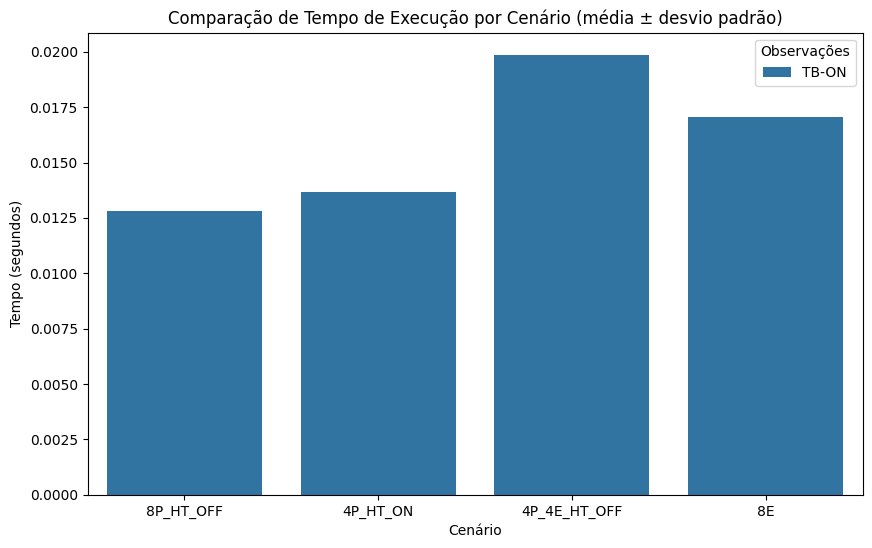

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Supondo que seus arquivos estejam em CSV
df1 = pd.read_csv('experimentos03-threading/20251121_065331_matrix1000_numruns1_performance.csv') # Com Turbo Bost
#df2 = pd.read_csv('20251111_170848_matrix1000_numruns5_performance.csv') 

df1['Dataset'] = 'TB-ON'
#df2['Dataset'] = '-'

#df_combined = pd.concat([df1, df2], ignore_index=True)

plt.figure(figsize=(10,6))
#sns.barplot(x='Scenario', y='Time_sec', hue='Dataset', data=df_combined, ci='sd')
sns.barplot(
    x='Scenario',
    y='Time_sec',
    hue='Dataset',
    data=df1,
    estimator='mean'       # calcula a média automaticamente
    #errorbar='sd'           # mostra desvio padrão
)
plt.title('Comparação de Tempo de Execução por Cenário (média ± desvio padrão)')
plt.ylabel('Tempo (segundos)')
plt.xlabel('Cenário')
plt.legend(title='Observações')

# Salvar como PDF
#plt.savefig('grafico_time_sec.pdf', format='pdf', bbox_inches='tight')

# Salvar como PNG
plt.savefig('grafico_time_sec.png', format='png', dpi=300, bbox_inches='tight')

plt.show()